# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

### Overview (to be updated)
1. Import, load and preprocess data
2. Offline performance
3. Online simulation

### Import and load the data

In [1]:
# Imports
import pickle
import os
import re 
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA

# Loading and preprocessing functions
from utils.preprocessing import all_have_same_condition, list_iterations, load_complete_session, inspect_session, get_n_epochs, get_iterations, get_n_iterations, load_session_chached

# Feature extraction
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime

# Offline performance functions
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



### Calibration (Offline)
Using the data of session 3

#### Functions

#### Function call

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5160581473968897
AUC SLDA:  0.4964503042596349
AUC BT-LDA:  0.5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


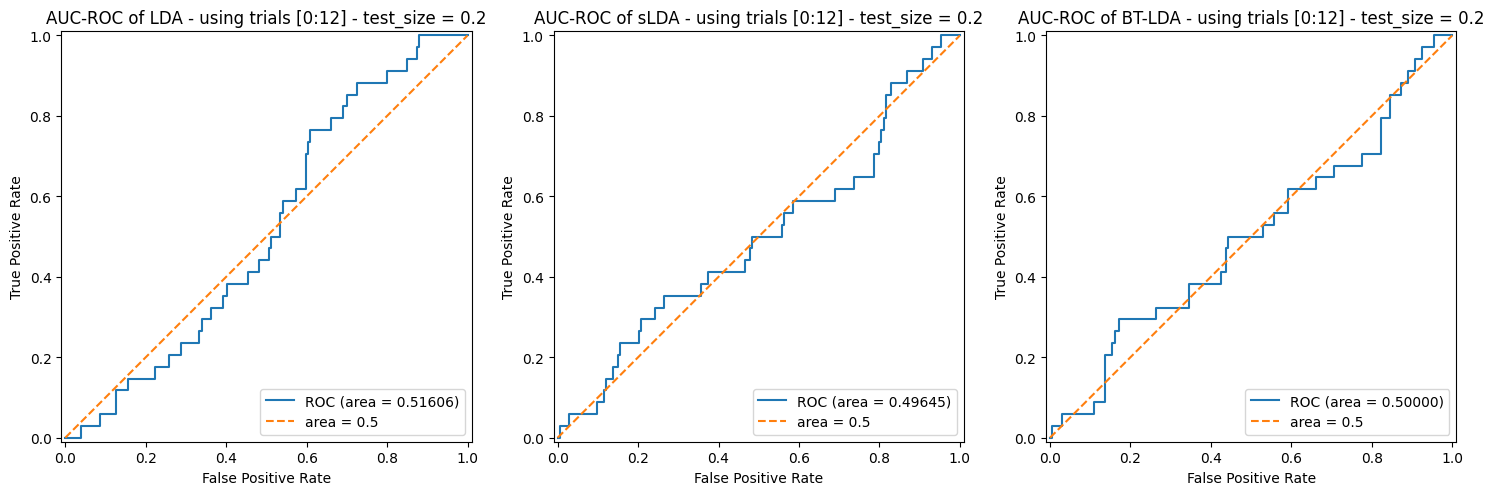

AUC score of LDA, all 4 folds: [0.55771086 0.49200337 0.48761843 0.52207149]
Mean AUC score of LDA: 		 0.5148510364423718
AUC score of sLDA, all 4 folds: [0.68084878 0.5770202  0.56147717 0.50990525]
Mean AUC score of sLDA: 	 0.5823128536463119
AUC score of BT-LDA, all 4 folds: [0.66359447 0.57544192 0.58161068 0.50872093]
Mean AUC score of BT-LDA: 	 0.5823419999796124


In [2]:
# Calibration/offline performance
trials, _, _ = load_session_chached("data_p1/P1_S3/anonymized")
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

compare_auc_single_trial_interval(trials, 0, 12, test_size=0.2, ival_bounds=clf_ival_boundaries, plot_roc_curves=True) 
compute_auc_with_cv(trials,0,12,ival_bounds=clf_ival_boundaries,cv_folds=4,show_mean=True,show_folds=True)

## Session 16

### Loading & preprocessing

In [5]:
# Load all runs of session 16
data_path_test = "data_p1/P1_S16/anonymized" 
trials, iterations, epochs = load_session_chached(data_path_test)
# for p1 s16, first runtime is 6 min 25 s
# for p1 s16, second runtime is 10 s
print(len(trials))
print(all_have_same_condition(data_path_test, show_conditions=True))


Loading file:  data_p1_P1_S16_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S16_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S16_anonymized.pkl
162
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
True


In [13]:
# visualize / inspect data
inspect_session("data_p1/P1_S16/anonymized")

Condition per run: 
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
All conditions of this session are the same:  True
Number of iterations per trial:
Run 0: [15  8  8  8  8  8]
Run 1: [ 8  8  8  8  8 13]
Run 2: [ 8  8  8  8 10  8]
Run 3: [8 8 8 8 8 8]
Run 4: [ 8  8  8  8  8 15]
Run 5: [8 8 8 8 8 8]
Run 6: [ 8 11  8  8  8  8]
Run 7: [ 8  8  8 10  8  8]
Run 8: [8 8 8 8 8 8]
Run 9: [15 14  8  8  8  8]
Run 10: [ 8  8 15  8 15  9]
Run 11: [ 8  8 11  8 15  8]
Run 12: [ 8 15  8  8 14 15]
Run 13: [8 8 8 8 8 8]
Run 14: [ 8 15  8 15  8  8]
Run 15: [8 8 8 8 8 8]
Run 16: [8 8 8 9 8 8]
Run 17: [8 8 8 8 8 8]
Run 18: [ 8  8  8  8 12  8]
Run 19: [ 8  8  8  8 10 11]
Run 20: [ 8 15 10  8  9  8]
Run 21: 

### Calibration / offline performance

948 epochs were used
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.9222705696202531
AUC SLDA:  0.9317642405063292


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


AUC BT-LDA:  0.9515427215189873


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


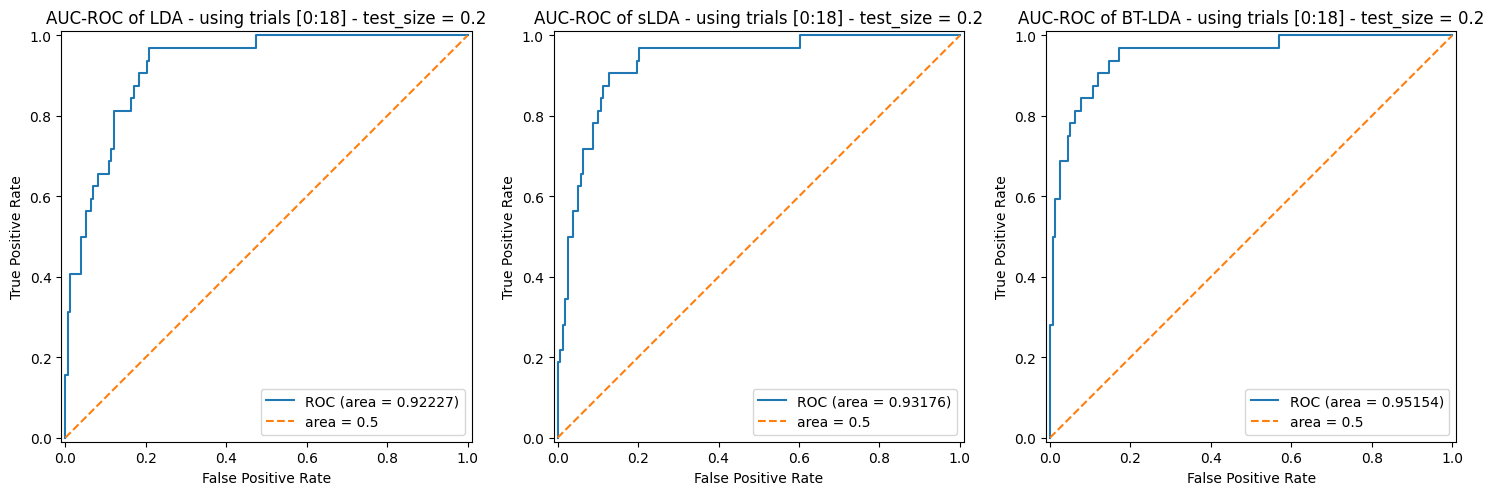

In [10]:
# Evaluating the calibration / offline performance
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
print("{} epochs were used".format(get_n_epochs(trials=trials[:18])))
compare_auc_single_trial_interval(trials,0,18,test_size=0.2,plot_roc_curves=True)


In [12]:
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)

Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.8711494336177077
Mean AUC score of sLDA: 	 0.8969877086628355
Mean AUC score of BT-LDA: 	 0.8967507793015408


#### Using smaller time intervals

In [16]:
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.arange(0.1,0.5,0.02)
print(clf_ival_boundaries)

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)

# Using different time intervals  
clf_ival_boundaries = np.arange(0.05,0.5,0.01)
print("\n",clf_ival_boundaries)

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)


[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48]
Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.6740371632503612
Mean AUC score of sLDA: 	 0.8709951098910489
Mean AUC score of BT-LDA: 	 0.8797369356062249

 [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32
 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46
 0.47 0.48 0.49]
Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.6388372449603414
Mean AUC score of sLDA: 	 0.8699995201264237
Mean AUC score of BT-LDA: 	 0.8868781857360538


## Online simulation


#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

#### Function

In [13]:
import logging
import math
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime

def online_simulation(raw_calibration_trials, online_trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None):

    if log_process is not None:
        # this was needed in order to create a log file
        for handler in logging.root.handlers[:]:
            logging.root.removeHandler(handler)

        logging.basicConfig(
            filename=log_process,
            encoding="utf-8",
            filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
            level=logging.DEBUG)

        logging.info("New log file")


    clf_ival_boundaries = ival_bounds
    # raw_calibration_trials = trials[0:12] # change start & stop trial
    # online_trials = trials[12:] 
    raw_calibration_trials = raw_calibration_trials

    ### Training the classifier ---------------------------------------------------------

    # calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    # calibration_trials_reshaped = [[epochs.transpose(0, 2, 1) for epochs in trial] for trial in calibration_trials]
    # calibration_stimuli = list()
    # for trial in calibration_trials_reshaped:
    #     for iteration in trial:
    #         for epoch in iteration:
    #             calibration_stimuli.append(epoch.reshape(-1)) 
    # calibration_stimuli = np.array(calibration_stimuli)
    # calibration_labels = list()
    # for trial in raw_calibration_trials:
    #     for iteration in trial:
    #         for event in iteration.events[:,2]:
    #             calibration_labels.append(1 if event > 107 else 0)
    # calibration_labels = np.array(calibration_labels) 
    # X = calibration_stimuli
    # y = calibration_labels

    X, y = epoch_vectorizer(raw_calibration_trials=raw_calibration_trials)

    # Evaluation of ex. 3 

    ### LDA
    ldaclf = make_pipeline(LDA(),)
    ldaclf.fit(X,y)
    #print(ldaclf.get_params)

    ### Shrinkage LDA
    slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    slda.fit(X,y)

    ### BT-LDA
    # problem: we have 63 channels in s1,s2 but 31 channels in the other sessions.
    # nch = (trials[0][0]).info["nchan"]
    nch = (raw_calibration_trials[0][0]).info["nchan"]
    btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    btlda.fit(X,y)

    if log_process:
        logging.info("Trained all three classifiers on the calibration data.")
        logging.info("Online simulation starts")

    ### Online simulation ------------------------------------------------------------------

    # Extract relevant data, labels and the played words

    # Using list comprehension
    online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
    online_labels = [(1 if event > 107 else 0) for trial in online_trials for iteration in trial for event in iteration.events[:,2]]            
    online_labels = np.array(online_labels) # conversion to np array is maybe not even needed
    online_words = [(iteration.events[:,2]%10) for trial in online_trials for iteration in trial]
    online_words = np.array(online_words) # conversion to np array is maybe not even needed

    # online_trial_targets: the target word per trial
    # print(len(online_trial_targets)) # e.g. 150
    # print(online_trial_targets[:10]) # e.g. [4 5 6 2 3 1 1 6 2 4]

    # online_labels: the location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
    # print(len(online_labels)) # e.g. 8244 = labels of all epochs (= n_trials * n_iterations per trial * n_epochs per iteration)
    # print(online_labels[:18]) # e.g. [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
   
    # #online_words: The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.
    # print(len(online_words)) # e.g. 1374
    #print(online_words[:6]) # e.g. [[1 6 2 3 5 4]
                             #       [6 3 1 2 4 5]
                             #       [6 3 5 2 1 4]
                             #       [3 1 2 6 4 5]
                             #       [1 6 5 2 4 3]
                             #       [5 4 1 6 2 3]]
    print(online_words.shape) # (n_trials * avg_n_iterations_p_trial, 6)

    if log_process:
        logging.info("Number of online trials: {}, which is {} runs".format(len(online_trials), len(online_trials)/6))


    # Predict target/non-target per stimulus.

    signed_distances_lda = np.zeros(len(online_labels))
    signed_distances_slda = np.zeros(len(online_labels))
    signed_distances_btlda = np.zeros(len(online_labels))

    count = 0 
    played_word_count = 0

    # word decision
    trial_predictions_lda = np.zeros(online_trial_targets.shape)
    trial_predictions_slda = np.zeros(online_trial_targets.shape)
    trial_predictions_btlda = np.zeros(online_trial_targets.shape)


    for t, trial in enumerate(online_trials):
        print("trial {}/{}".format(t, len(online_trials)))
        if log_process:
            logging.info("------------------ Run {} Trial {} ------------------".format(math.trunc(t/6)+1,t+1))
            logging.info("{epoch} \t| {word_id} \t| {LDA} \t| {SLDA} \t| {BTLDA} ")

        stim_distances_lda = np.zeros((len(trial),6))
        stim_distances_slda = np.zeros((len(trial),6))
        stim_distances_btlda = np.zeros((len(trial),6))

        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                s1 = (ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_lda[count] = s1 # Compute signed distance of stimulus to decision boundary

                s2 = (slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_slda[count] = s2 # Compute signed distance of stimulus to decision boundary

                s3 = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()
                signed_distances_btlda[count] = s3 # Compute signed distance of stimulus to decision boundary
                
                if log_process:
                    logging.info("{} \t| {} \t| {} \t| {} \t| {}".format(count, iteration[s].events[:,2], s1, s2, s3))

                # for word decision
                played_word = online_words[played_word_count,s] - 1 # convert to index
                stim_distances_lda[i,played_word] = s1 # order computed distances according to word id
                stim_distances_slda[i,played_word] = s2
                stim_distances_btlda[i,played_word] = s3 
                count+=1

                # Important note during debugging
                # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            
            played_word_count += 1

        means_lda = np.mean(stim_distances_lda, axis=0) # get the mean distance for each word
        means_slda = np.mean(stim_distances_slda, axis=0) # get the mean distance for each word
        means_btlda = np.mean(stim_distances_btlda, axis=0) # get the mean distance for each word

        best_guess_lda = np.argmax(means_lda)
        best_guess_slda = np.argmax(means_slda)
        best_guess_btlda = np.argmax(means_btlda)

        # best_distances_lda = stim_distances_lda[:, best_guess_lda].flatten()
        # best_distances_slda = stim_distances_slda[:, best_guess_slda].flatten()
        # best_distances_btlda = stim_distances_btlda[:, best_guess_btlda].flatten()

        #not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
        #t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)

        trial_predictions_lda[t] = best_guess_lda + 1
        trial_predictions_slda[t] = best_guess_slda + 1
        trial_predictions_btlda[t] = best_guess_btlda + 1

        #print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p)) 
        if log_process:
            logging.info("------------------ End of trial ------------------".format(math.trunc(t/6)+1,t+1))
            logging.info("{real_word} \t| {LDA_prediction} \t| {SLDA_prediction} \t| {BTLDA_prediction} ")
            logging.info("{} \t| {} \t| {} \t| {} ".format(online_trial_targets[t],best_guess_lda+1,best_guess_slda+1,best_guess_btlda+1))

    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_lda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the LDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_slda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the sLDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_btlda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
    plt.show()

    # word prediction
    
    # plot_distribution_comparison(not_best_distances, best_distances)
    print("Accuracy LDA: %0.5f" % np.mean(trial_predictions_lda == online_trial_targets))
    print("Accuracy SLDA: %0.5f" % np.mean(trial_predictions_slda == online_trial_targets))
    print("Accuracy BT-LDA: %0.5f" % np.mean(trial_predictions_btlda == online_trial_targets))

    if log_process:
        logging.info("Accuracy LDA: %0.5f" % np.mean(trial_predictions_lda == online_trial_targets))
        logging.info("Accuracy SLDA: %0.5f" % np.mean(trial_predictions_slda == online_trial_targets))
        logging.info("Accuracy BT-LDA: %0.5f" % np.mean(trial_predictions_btlda == online_trial_targets))

    return online_trial_targets


ImportError: cannot import name 'epoch_vectorizer_channelprime' from 'utils.feature_extraction' (c:\Users\Soz\OneDrive - Radboud Universiteit\Bureaublad\BSc_Thesis\Code\BSc_Thesis_Project\ERP_analysis_code\patient_pipeline\utils\feature_extraction.py)

#### Function call

(142, 6)
trial 0/10
trial 1/10
trial 2/10
trial 3/10
trial 4/10
trial 5/10
trial 6/10
trial 7/10
trial 8/10
trial 9/10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


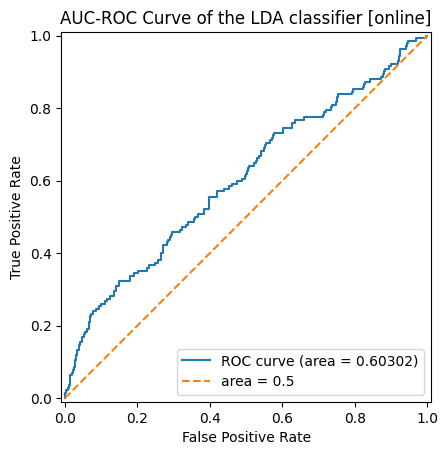

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


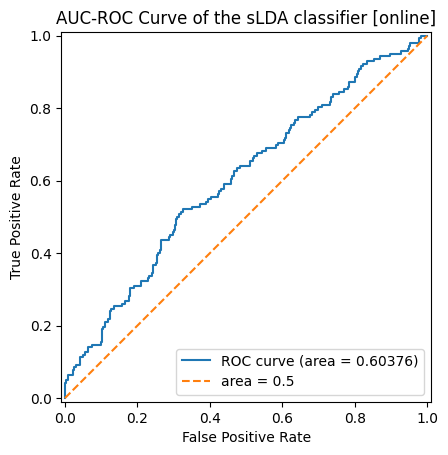

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


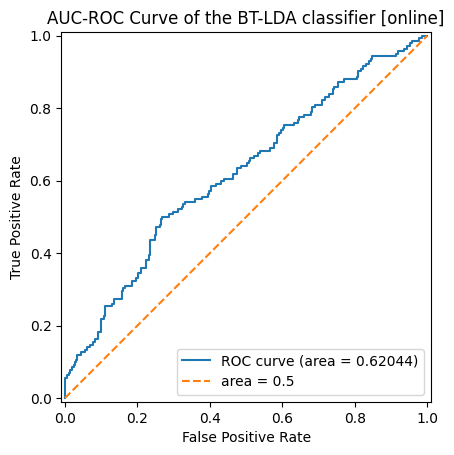

Accuracy LDA: 0.50000
Accuracy SLDA: 0.70000
Accuracy BT-LDA: 0.70000
CPU times: total: 20.1 s
Wall time: 21 s


In [12]:
# 08-05-2025 09:27 further optimizing, code cleanup
# timeit outcome
# 54.1 s ± 893 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

calibration_trials = trials[0:12]
online_trials = trials[12:22]
%time online_trial_targets = online_simulation(calibration_trials, online_trials)


## Real online simulation

### Simulate session 3 (trained on sessions 1 and 2)

Procedure
1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.
2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)
3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl

Trials of session 1:  12
Trials of session 2:  18
All calibration trials:  30
That is 2700 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5307901234567901
AUC SLDA:  0.5837037037037037
AUC BT-LDA:  0.5758271604938271


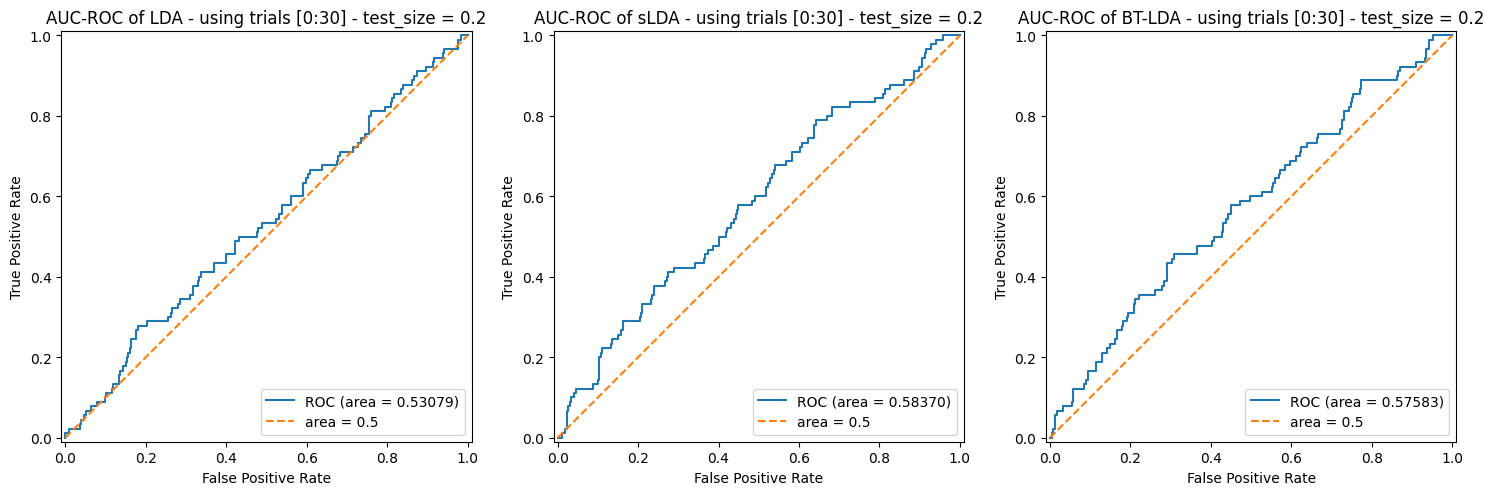

Mean AUC score of LDA: 		 0.5706606665905883
Mean AUC score of sLDA: 	 0.5926908362969345
Mean AUC score of BT-LDA: 	 0.5937643368563904


In [192]:
# 1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.

trials_s1, iterations_s1, epochs_s1 = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
trials_s2, iterations_s2, epochs_s2 = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

print("\nTrials of session 1: ",len(trials_s1))
print("Trials of session 2: ",len(trials_s2))

calibration_trials = trials_s1 + trials_s2
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

del trials_s1
del trials_s2

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
(1197, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/8

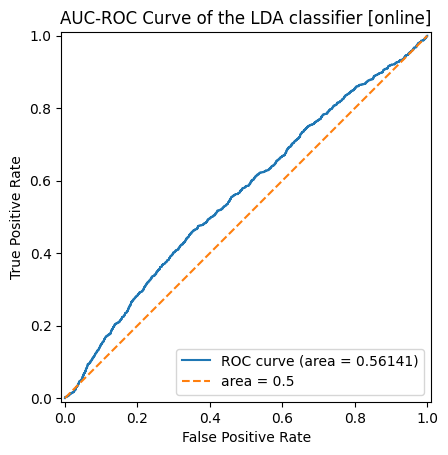

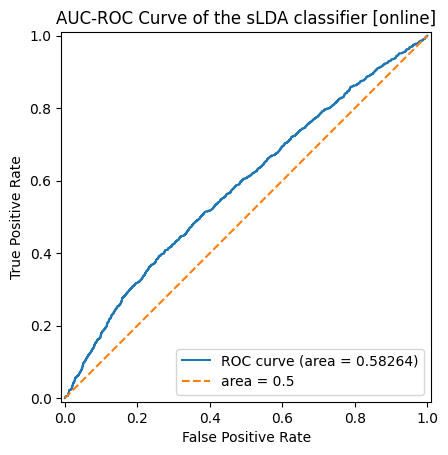

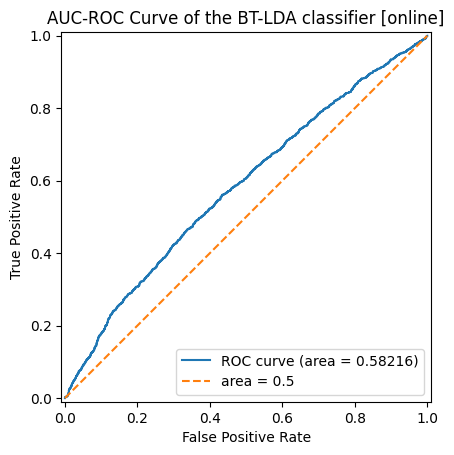

Accuracy LDA: 0.36905
Accuracy SLDA: 0.51190
Accuracy BT-LDA: 0.47619


In [150]:
# online simulation static (trained on sessions 1,2 - applied on session 3)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3
# runtime 1 min
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_static_s3.log")


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
(1197, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/8

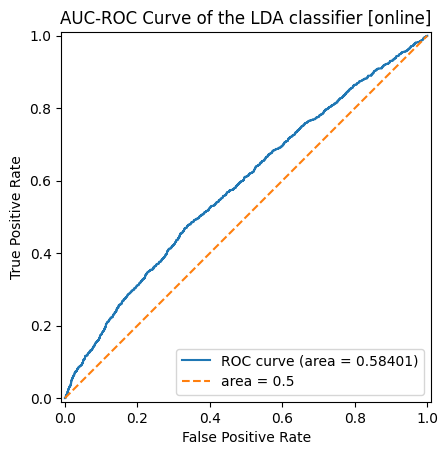

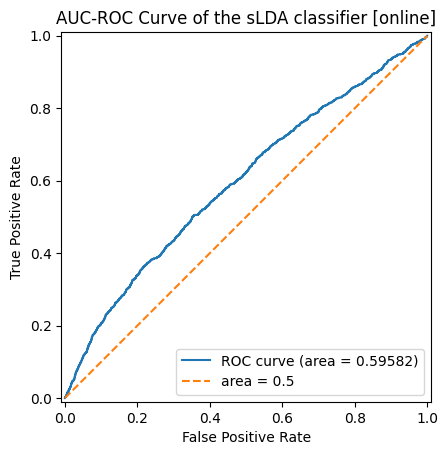

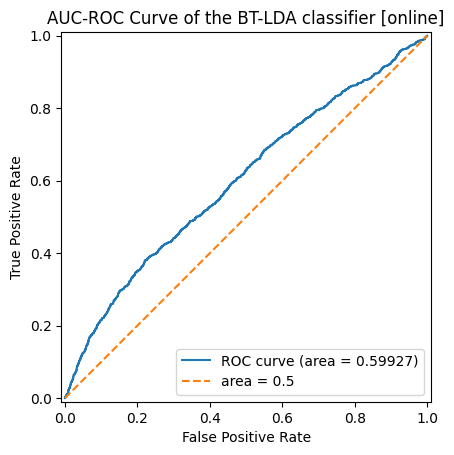

Accuracy LDA: 0.53571
Accuracy SLDA: 0.55952
Accuracy BT-LDA: 0.57143


In [198]:
# Adaptation: sliding window

# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_adaptation_simulation_sw(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_adaptive_s3.log")


## Adaptation

#### LDA class froms scratch


In [ ]:
class MyLDA:
    "LDA with convex combination adaptation"

    def __init__(self):
        self.trained = False
        self.w = None
        self.b = None
        self.S1 = None # cov matrix target class
        self.S2 = None # cov matrix non target class
        self.S_w = None # within class cov matrix
        self.m1 = None
        self.m2 = None

    def manual_cov_matrix(self, X):
        """cov matrix from scratch
        
        inputs:
        X: data of dimensionality N x D
        
        Note that np.cov(X) accepts data of dimensionality D x N  !
        """

        m = np.mean(X,0)
        N = X.shape[0]
        X_mean_centered = X - m
        cov_matrix = 1/(N-1) * (np.dot(np.transpose(X_mean_centered),(X_mean_centered)))
        return cov_matrix   
         
    def fit(self, X, y):
        """LDA from scratch for binary classes
        
        inputs:
        - X: data of dimensionality N x D
        - y: labels of dimensionality N. 
            takes values {1,2}
        
        outputs: 
        - w: weight vector 
        - b: bias (scalar)
        """
        
        # Extract class data matrix 
        X_class_1 = X[y==1]
        X_class_2 = X[y==2]

        # Obtain the class means (take mean across samples N)
        m1 = np.mean(X_class_1,0) 
        m2 = np.mean(X_class_2,0)

        # Compute the cov matrix manually (see function manual_cov_matrix() above)
        S1 = self.manual_cov_matrix(X_class_1)
        S2 = self.manual_cov_matrix(X_class_2)

        # Compute the weight vector
        S_w = 0.5 * (S1 + S2)
        w = np.dot ( np.linalg.pinv(S_w) , m2 - m1)
        b = -0.5 * np.dot(w.T,(m1 + m2))

        self.m1 = m1
        self.m2 = m2
        self.S1 = S1
        self.S2 = S2
        self.S_w = S_w
        self.w = w
        self.b = b
        self.trained = True

    def decision_function(self, X):
        assert self.trained is True, "Classifier has not been trained yet"
        distance = np.dot(X,self.w.T) + self.b
        return distance
    
    
        


In [197]:
# Test whether my LDA works as sklearn's LDA
# Creating fake data X and y
X_train = [[3,20],
     [2,7],
     [1,10],
     [6,24],
     [1,7],
     [8,19],
     [1,8],
     [5,21]]
X_train = np.array(X_train) 

# X has dimensionality N x D
# print(X.shape) # (8,2)

# Corresponding labels (1: class 0, 2: class 1) 
# Note that the classes are of equal size
y_train = np.array([1, 2, 2, 1, 2, 1, 2, 1])

# Compute output of my LDA
myclf = MyLDA()
myclf.fit(X_train,y_train) 
print("Trained LDA from scratch")
print("Obtained w vector w = \t\t", myclf.w)
print("Obtained bias b = \t\t",myclf.b)   

# Testing decision_function()
x = [[2, 6],[1,7]]
y = [1,2]
print("MyLDA decision function: \t\t",myclf.decision_function(x))

# Compute output of sklearn's LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA 
clf = LDA()
clf.fit(X_train, y_train)

print("\nTrained LDA from sklearn")
print("Obtained w vector w = \t\t",clf.coef_[0])
print("Obtained bias b = \t\t", clf.intercept_[0])
print("sklearn's LDA decision function: \t",clf.decision_function(x))

Trained LDA from scratch
Obtained w vector w = 		 [-2.45756458 -4.14575646]
Obtained bias b = 		 68.40774907749076
MyLDA decision function: 		 [38.61808118 36.9298893 ]

Trained LDA from sklearn
Obtained w vector w = 		 [-2.45756458 -4.14575646]
Obtained bias b = 		 68.40774907749076
sklearn's LDA decision function: 	 [38.61808118 36.9298893 ]


### Sliding window (external)

In [201]:
def online_adaptation_simulation_sw(raw_calibration_trials, online_trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None):

    if log_process is not None:
        for handler in logging.root.handlers[:]:
            logging.root.removeHandler(handler)

        logging.basicConfig(
            filename=log_process,
            encoding="utf-8",
            filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
            level=logging.DEBUG)

        logging.info("New log file")


    clf_ival_boundaries = ival_bounds
    raw_calibration_trials = raw_calibration_trials

    ### Training the classifier ---------------------------------------------------------

    calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    calibration_trials_reshaped = [[epochs.transpose(0, 2, 1) for epochs in trial] for trial in calibration_trials]
    calibration_stimuli = [epoch.reshape(-1) for trial in calibration_trials_reshaped for iteration in trial for epoch in iteration]
    calibration_stimuli = np.array(calibration_stimuli)
    calibration_labels = [(1 if event > 107 else 0) for trial in raw_calibration_trials for iteration in trial for event in iteration.events[:,2]] 
    calibration_labels = np.array(calibration_labels) 
    X_train = calibration_stimuli
    y_train = calibration_labels

    ### LDA
    ldaclf = make_pipeline(LDA(),)
    ldaclf.fit(X_train,y_train)

    ### Shrinkage LDA
    slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    slda.fit(X_train,y_train)

    ### BT-LDA
    nch = (raw_calibration_trials[0][0]).info["nchan"] # assuming nchan is constant in all trials
    btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    btlda.fit(X_train,y_train)

    if log_process:
        logging.info("Trained all three classifiers on the calibration data.")
        logging.info("Online simulation starts")

    ### Online simulation ------------------------------------------------------------------

    # Extract relevant data, labels and the played words

    # Using list comprehension
    online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
    online_labels = [(1 if event > 107 else 0) for trial in online_trials for iteration in trial for event in iteration.events[:,2]]            
    online_labels = np.array(online_labels) # conversion to np array is maybe not even needed
    online_words = [(iteration.events[:,2]%10) for trial in online_trials for iteration in trial]
    online_words = np.array(online_words) # conversion to np array is maybe not even needed

    # online_trial_targets: the target word per trial
    # print(len(online_trial_targets)) # e.g. 150
    # print(online_trial_targets[:10]) # e.g. [4 5 6 2 3 1 1 6 2 4]

    # online_labels: the location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
    # print(len(online_labels)) # e.g. 8244 = labels of all epochs (= n_trials * n_iterations per trial * n_epochs per iteration)
    # print(online_labels[:18]) # e.g. [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
   
    # #online_words: The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.
    # print(len(online_words)) # e.g. 1374
    #print(online_words[:6]) # e.g. [[1 6 2 3 5 4]
                             #       [6 3 1 2 4 5]
                             #       [6 3 5 2 1 4]
                             #       [3 1 2 6 4 5]
                             #       [1 6 5 2 4 3]
                             #       [5 4 1 6 2 3]]
    print(online_words.shape) # (n_trials * avg_n_iterations_p_trial, 6)

    if log_process:
        logging.info("Number of online trials: {}, which is {} runs".format(len(online_trials), len(online_trials)/6))


    # Predict target/non-target per stimulus.

    signed_distances_lda = np.zeros(len(online_labels))
    signed_distances_slda = np.zeros(len(online_labels))
    signed_distances_btlda = np.zeros(len(online_labels))

    count = 0 
    played_word_count = 0

    # word decision
    trial_predictions_lda = np.zeros(online_trial_targets.shape)
    trial_predictions_slda = np.zeros(online_trial_targets.shape)
    trial_predictions_btlda = np.zeros(online_trial_targets.shape)


    for t, trial in enumerate(online_trials):
        print("trial {}/{}".format(t, len(online_trials)))
        if log_process:
            logging.info("------------------ Run {} Trial {} ------------------".format(math.trunc(t/6)+1,t+1))
            logging.info("{epoch} \t| {word_id} \t| {LDA} \t| {SLDA} \t| {BTLDA} ")

        stim_distances_lda = np.zeros((len(trial),6))
        stim_distances_slda = np.zeros((len(trial),6))
        stim_distances_btlda = np.zeros((len(trial),6))

        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                s1 = (ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_lda[count] = s1 # Compute signed distance of stimulus to decision boundary

                s2 = (slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_slda[count] = s2 # Compute signed distance of stimulus to decision boundary

                s3 = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()
                signed_distances_btlda[count] = s3 # Compute signed distance of stimulus to decision boundary
                
                if log_process:
                    logging.info("{} \t| {} \t| {} \t| {} \t| {}".format(count, iteration[s].events[:,2], s1, s2, s3))

                # for word decision
                played_word = online_words[played_word_count,s] - 1 # convert to index
                stim_distances_lda[i,played_word] = s1 # order computed distances according to word id
                stim_distances_slda[i,played_word] = s2
                stim_distances_btlda[i,played_word] = s3 

                ### adaptation (sliding window)
                new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)
                new_single_label = online_labels[count]
                # update X_train and y_train data
                X_train = np.append(X_train,new_single_epoch, axis=0)
                X_train = X_train[1:]
                y_train = np.append(y_train,new_single_label)
                y_train = y_train[1:]
                # only apply this new training data to update our classifier after a single trial

                count+=1

                # Important note during debugging
                # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            
            played_word_count += 1

        means_lda = np.mean(stim_distances_lda, axis=0) # get the mean distance for each word
        means_slda = np.mean(stim_distances_slda, axis=0) # get the mean distance for each word
        means_btlda = np.mean(stim_distances_btlda, axis=0) # get the mean distance for each word

        best_guess_lda = np.argmax(means_lda)
        best_guess_slda = np.argmax(means_slda)
        best_guess_btlda = np.argmax(means_btlda)

        # best_distances_lda = stim_distances_lda[:, best_guess_lda].flatten()
        # best_distances_slda = stim_distances_slda[:, best_guess_slda].flatten()
        # best_distances_btlda = stim_distances_btlda[:, best_guess_btlda].flatten()

        #not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
        #t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)

        trial_predictions_lda[t] = best_guess_lda + 1
        trial_predictions_slda[t] = best_guess_slda + 1
        trial_predictions_btlda[t] = best_guess_btlda + 1

        ### Adaptation: update our classifier after a trial has finished
        ## LDA
        ldaclf = make_pipeline(LDA(),)
        ldaclf.fit(X_train,y_train)
        ## Shrinkage LDA
        slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
        slda.fit(X_train,y_train)
        ## BT-LDA
        nch = (raw_calibration_trials[0][0]).info["nchan"] # assuming nchan is constant in all trials
        btlda = make_pipeline(
            ToeplitzLDA(n_channels=nch),
        )
        btlda.fit(X_train,y_train)


        #print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p)) 
        if log_process:
            logging.info("------------------ End of trial ------------------".format(math.trunc(t/6)+1,t+1))
            logging.info("{real_word} \t| {LDA_prediction} \t| {SLDA_prediction} \t| {BTLDA_prediction} ")
            logging.info("{} \t| {} \t| {} \t| {} ".format(online_trial_targets[t],best_guess_lda+1,best_guess_slda+1,best_guess_btlda+1))
            logging.info("Updated all three classifiers, this trial is now included in the training set")

    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_lda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the LDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_slda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the sLDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_btlda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
    plt.show()

    # word prediction
    
    # plot_distribution_comparison(not_best_distances, best_distances)
    print("Accuracy LDA: %0.5f" % np.mean(trial_predictions_lda == online_trial_targets))
    print("Accuracy SLDA: %0.5f" % np.mean(trial_predictions_slda == online_trial_targets))
    print("Accuracy BT-LDA: %0.5f" % np.mean(trial_predictions_btlda == online_trial_targets))

    if log_process:
        logging.info("Accuracy LDA: %0.5f" % np.mean(trial_predictions_lda == online_trial_targets))
        logging.info("Accuracy SLDA: %0.5f" % np.mean(trial_predictions_slda == online_trial_targets))
        logging.info("Accuracy BT-LDA: %0.5f" % np.mean(trial_predictions_btlda == online_trial_targets))

    return online_trial_targets


## Session 3

In [ ]:
# 1. Only load the runs of session 4 as training data.
trials_s1, _, _ = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
trials_s2, _, _ = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

print("\nTrials of session 1: ",len(trials_s1))
print("Trials of session 2: ",len(trials_s2))

calibration_trials = trials_s1 + trials_s2
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

del trials_s1
del trials_s2

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3
trials_s3, _, _ = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_static_s3.log")

# Adaptation: sliding window
# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

online_words_s3 = online_adaptation_simulation_sw(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_adaptive_sw_s3.log")

## Session 4 


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
All calibration trials:  84
That is 7182 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6471140883341133
AUC SLDA:  0.6523843784270856
AUC BT-LDA:  0.6608957746872403


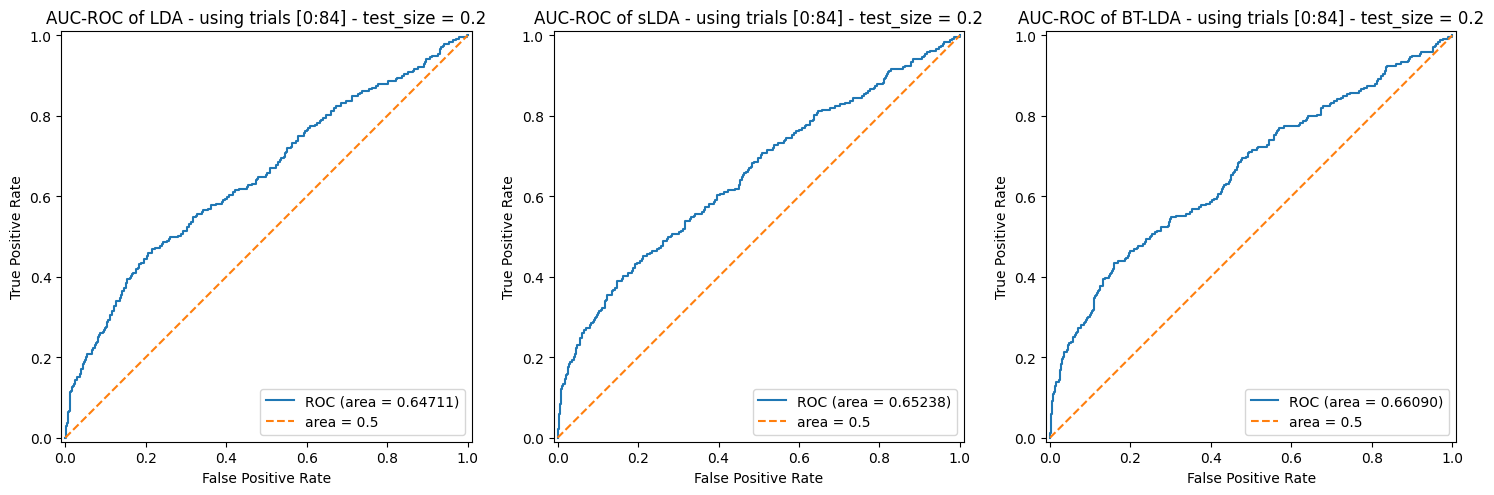

Mean AUC score of LDA: 		 0.6092158900971332
Mean AUC score of sLDA: 	 0.6113796577895476
Mean AUC score of BT-LDA: 	 0.6146664599894142
Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl
(1371, 6)
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
trial 48/102
trial 49/102
trial 50/102
trial 51/102
t

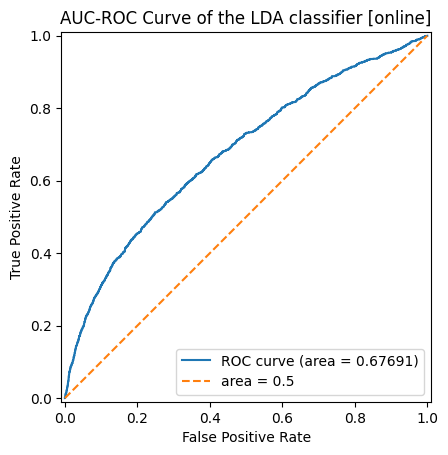

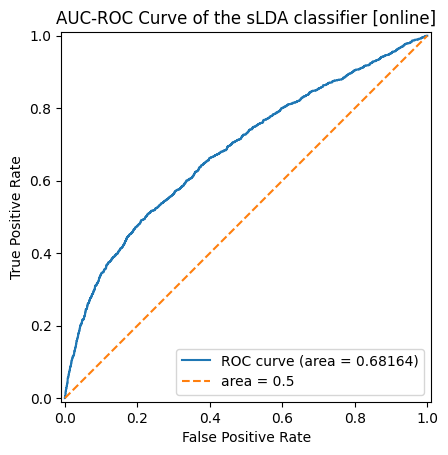

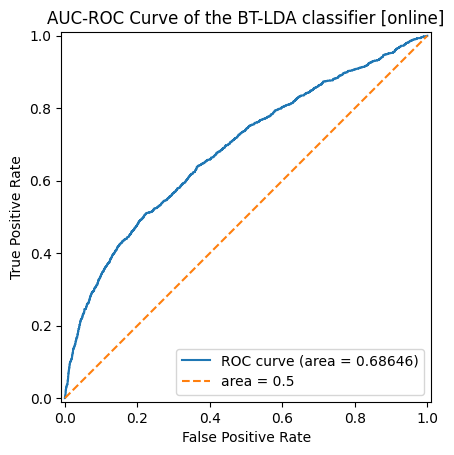

Accuracy LDA: 0.71569
Accuracy SLDA: 0.68627
Accuracy BT-LDA: 0.69608


In [157]:
# 1. Only load the runs of session 3 as training data.
calibration_trials, _, _ = load_session_chached("data_p1/P1_S3/anonymized")

print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

# 2. Train a classifier and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 4
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized", selection = None)

online_words_s4 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s4, log_process="online_static_s4.log")

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl
(1371, 6)
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
tria

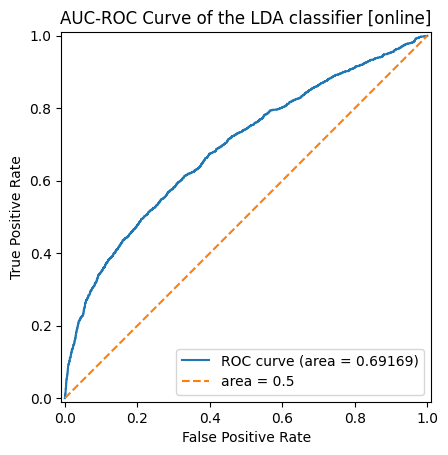

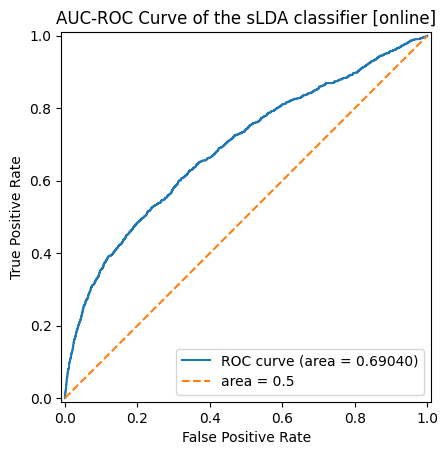

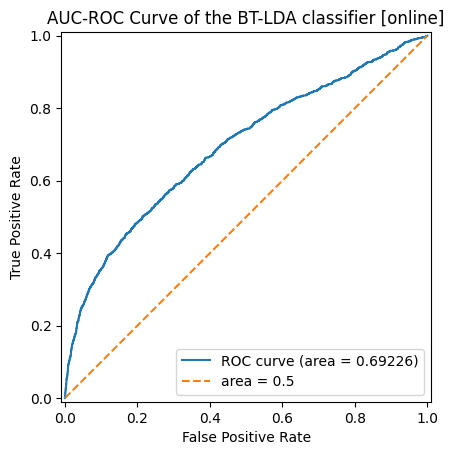

Accuracy LDA: 0.69608
Accuracy SLDA: 0.67647
Accuracy BT-LDA: 0.68627


In [202]:
# Adaptation: sliding window

# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized", selection = None)

online_words_s4 = online_adaptation_simulation_sw(raw_calibration_trials=trials_s3, online_trials=trials_s4, log_process="online_adaptive_sw_s4.log")



## Session 5

Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl


All calibration trials:  102
That is 8226 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6949921261518163
AUC SLDA:  0.7073615160349853
AUC BT-LDA:  0.7061032963759017


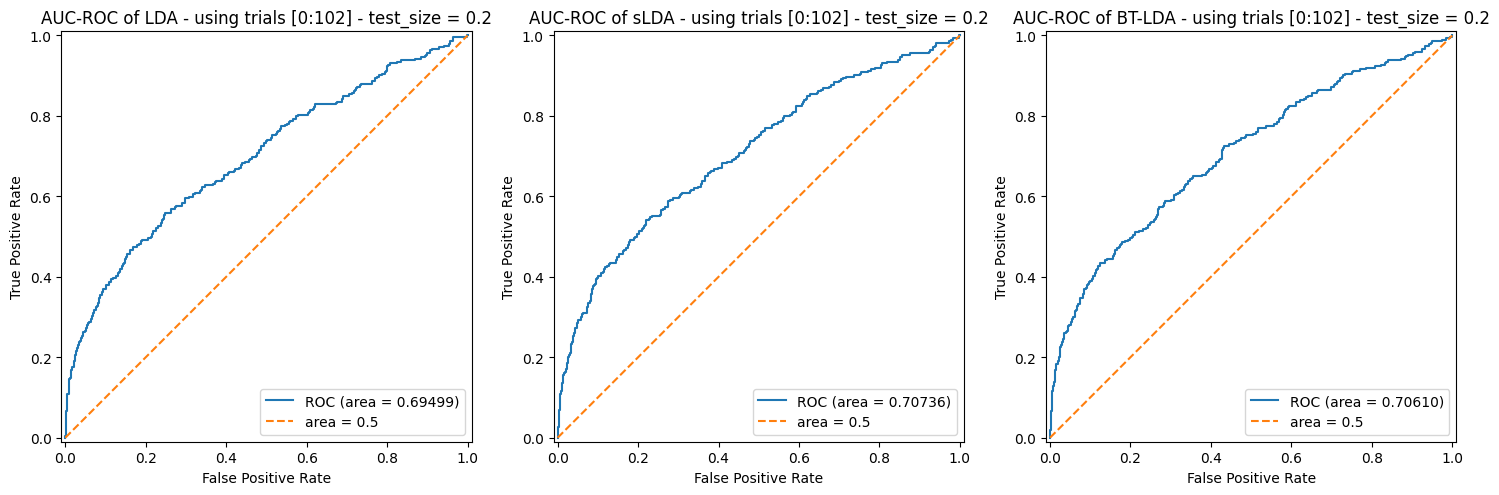

Mean AUC score of LDA: 		 0.6941367469916186
Mean AUC score of sLDA: 	 0.6940095798380344
Mean AUC score of BT-LDA: 	 0.6949448362732878
Loading file:  data_p1_P1_S5_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S5_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S5_anonymized.pkl
(1055, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial

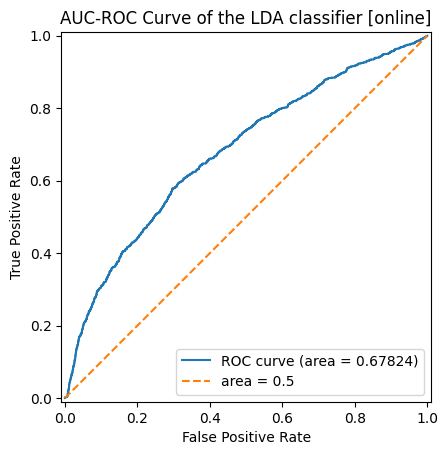

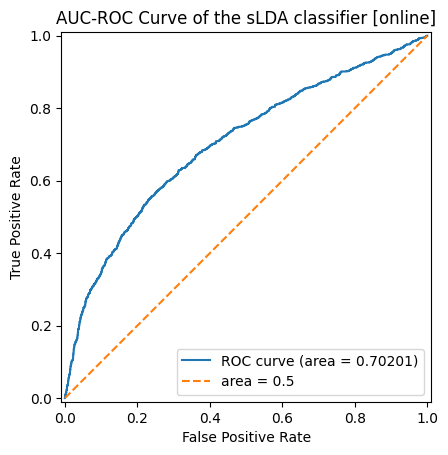

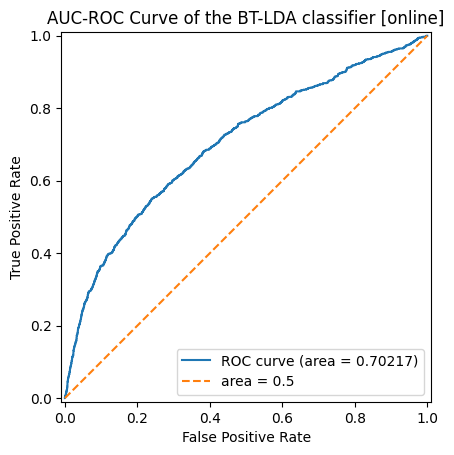

Accuracy LDA: 0.66667
Accuracy SLDA: 0.70238
Accuracy BT-LDA: 0.71429
(1055, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/84
trial 72/84
trial 73/84
trial 74/84
trial 75/84
trial 76/84
trial 

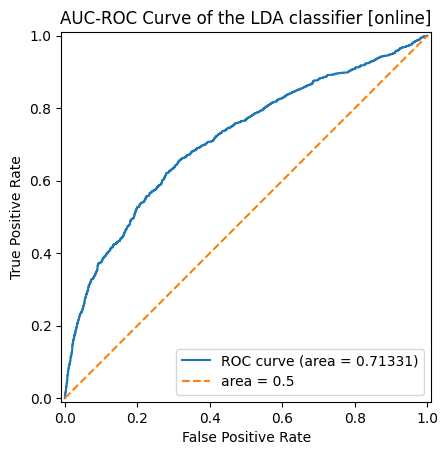

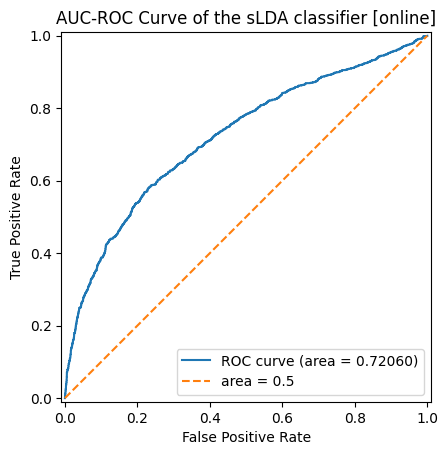

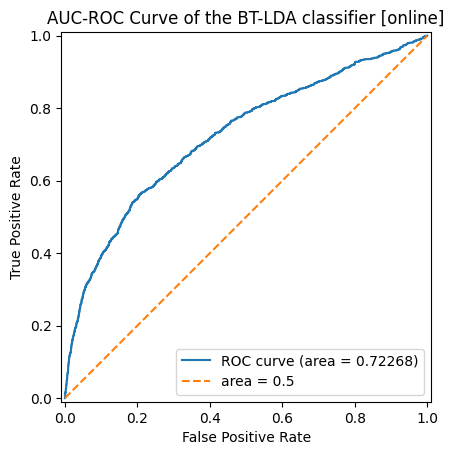

Accuracy LDA: 0.73810
Accuracy SLDA: 0.73810
Accuracy BT-LDA: 0.73810


In [203]:
# 1. Only load the runs of session 4 as training data.
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized")

print("All calibration trials: ",len(trials_s4))
print("That is {} epochs\n".format(get_n_epochs(trials_s4)))

# 2. Train a classifier and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(trials_s4, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(trials_s4, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 5
trials_s5, _, _ = load_session_chached("data_p1/P1_S5/anonymized", selection = None)

online_words_s5 = online_simulation(raw_calibration_trials=trials_s4, online_trials=trials_s5, log_process="online_static_s5.log")

# Adaptation: sliding window
# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

online_words_s5 = online_adaptation_simulation_sw(raw_calibration_trials=trials_s4, online_trials=trials_s5, log_process="online_adaptive_sw_s5.log")
